# HW2 : Cross-Validation and  Regularization

### Configuration and imports


In [83]:
import os
import numpy as np
import pandas as pd
 
import sklearn.preprocessing
import sklearn.pipeline
import sklearn.linear_model
import sklearn.metrics
import sklearn.model_selection


In [84]:
from matplotlib import pyplot as plt

import seaborn as sns
#This sets the default style for all figures. 
sns.set_theme('notebook', font_scale=1.25, style='whitegrid')

You may need to adjust your data directory to point towards the auto data. Please do not adjust the random seed for the version of your results you turn in.  

In [85]:
SEED = 12345 

DATA_DIR = 'data_auto/'

## Helper Functions

Here we provide some functions you may find useful for your analysis. You are not **required** to use these helper functions, but you may find them useful.

### Data Loading 

In [86]:
def load_2d_arr_from_csv(fname, include_header=False):
    x = np.loadtxt(os.path.join(DATA_DIR, fname), delimiter=',', skiprows=1)
    assert x.ndim == 2
    if include_header:
        header_cols = np.loadtxt(os.path.join(DATA_DIR, fname), delimiter=',', dtype=str)[0].tolist()
        return x, header_cols
    else:
        return x
    
def load_1d_arr_from_csv(fname):
    x = np.loadtxt(os.path.join(DATA_DIR, fname), delimiter=',', skiprows=1)
    if x.ndim == 1:
        return x
    else:
        raise ValueError("Not 1d")

These functions can then be used as follows.

In [87]:
x_tr_MF, xcolnames_F = load_2d_arr_from_csv('x_train.csv', include_header=True)
x_va_NF = load_2d_arr_from_csv('x_valid.csv')
x_te_PF = load_2d_arr_from_csv('x_test.csv')

y_tr_M = load_1d_arr_from_csv('y_train.csv')
y_va_N = load_1d_arr_from_csv('y_valid.csv')
y_te_P = load_1d_arr_from_csv('y_test.csv')

print(xcolnames_F)
print(x_tr_MF[:5])
print(y_tr_M[:5,np.newaxis])

['horsepower', 'weight', 'cylinders', 'displacement']
[[ 115. 2595.    6.  173.]
 [ 180. 4380.    8.  350.]
 [ 150. 4457.    8.  318.]
 [ 105. 3897.    6.  250.]
 [ 193. 4732.    8.  304.]]
[[28.8]
 [16.5]
 [14. ]
 [16. ]
 [ 9. ]]


## Plotting

In [88]:
def plot_train_and_valid_error_vs_hyper(
        hyper_list, err_tr_list=None, err_va_list=None,
        ymax=40,
        leg_loc='upper right',
        xlabel='polynomial degree',
        ylabel='RMSE',
        title=''):
    if err_va_list is not None:
        plt.plot(hyper_list, err_va_list, 'rs-', label='valid');
    if err_tr_list is not None:
        plt.plot(hyper_list, err_tr_list, 'bd:', label='train');
    plt.ylim([0, ymax]);
    plt.legend(loc=leg_loc);
    plt.xlabel(xlabel);
    plt.ylabel(ylabel);
    plt.title(title)

## Building a regression pipeline

### Sanitizing output
You should sanitize any model's predictions to help ensure the predicted values that are physically plausible. 
We are predicting MPG, which should 
* (1) always be positive, and
* (2) will probably never exceed 120% of the largest value we see in train data

Predictions should be sanitized before being used to calculate errors or select best-performing models for your report. 

In [89]:
Y_MAX = 60.0 # The max MPG is about 48 in the training set

def sanitize(yhat_N):
    yhat_N = np.maximum(yhat_N, 0)
    yhat_N = np.minimum(yhat_N, Y_MAX)
    return yhat_N

### Creating multiple pipelines

This function returns a scikit-learn `pipeline` that of the specified degree. 
You'll need to make a version that takes in an additional parameter, `alpha` and use `sklearn.linear_model.Ridge` to create ridge polynomial regression pipelines. 

In [90]:
def make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=1, remove_minmax_scaler=False):
    if remove_minmax_scaler:
        pipeline = sklearn.pipeline.Pipeline(
        steps=[
         ('poly_transformer', sklearn.preprocessing.PolynomialFeatures(degree=degree, include_bias=False)),
         ('regr', sklearn.linear_model.LinearRegression())
        ])
    else:
        pipeline = sklearn.pipeline.Pipeline(
            steps=[
            ('rescaler', sklearn.preprocessing.MinMaxScaler()),
            ('poly_transformer', sklearn.preprocessing.PolynomialFeatures(degree=degree, include_bias=False)),
            ('regr', sklearn.linear_model.LinearRegression())
            ])
        
    # Return the constructed pipeline
    # We can treat it as if it has a 'regression' API
    # e.g. a fit and a predict method
    return pipeline

### Inspecting learned weights

We can access individual steps of the pipeline to extract information, as demonstrated in the blow function.

In [91]:
def pretty_print_learned_weights(pipeline, xcolnames_F):
    ''' Print the learned parameters of given pipeline.
        Note that this function assumes that the pipeline has the named steps "poly_transformer" and "regr"
    '''
    my_lin_regr = pipeline.named_steps['regr']

    feat_names = pipeline.named_steps['poly_transformer'].get_feature_names_out()
    coef_values = my_lin_regr.coef_

    print("intercept: %.2f" % (my_lin_regr.intercept_))
    print("")

    print("%9s   %s" % ("weight", "feature var"))
    for feat, coef in zip(feat_names, coef_values):
        print("% 9.2f * %s" % (coef, feat))
    
    print("where ")
    for ff, colname in enumerate(xcolnames_F):
        print("x%d = %s" % (ff, colname))

# Your Code

In [92]:
# Model 0: Baseline Guess-Train-Set-Mean
y_bar = y_tr_M.mean()
y_bar

yhat_mean = np.ones(y_te_P.shape)
yhat_mean *= y_bar

guessing_te_err = sklearn.metrics.root_mean_squared_error(yhat_mean, y_te_P)
print("Test RMSE of guessing mean of y in test set:", guessing_te_err)

Test RMSE of guessing mean of y in test set: 7.104481090304907


In [93]:
# Question 1a
lin_reg_pipeline = make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=1)
lin_reg_pipeline.fit(x_tr_MF, y_tr_M)
pretty_print_learned_weights(lin_reg_pipeline, xcolnames_F)

intercept: 34.07

   weight   feature var
   -10.43 * x0
   -18.23 * x1
    -1.15 * x2
     0.58 * x3
where 
x0 = horsepower
x1 = weight
x2 = cylinders
x3 = displacement


In [94]:
# Question 1b
lin_reg_poly4_pipeline = make_pipeline__unpenalized_linear_regr_with_poly_feats(degree=4)
lin_reg_poly4_pipeline.fit(x_tr_MF, y_tr_M)
pretty_print_learned_weights(lin_reg_poly4_pipeline, xcolnames_F)

intercept: -123.11

   weight   feature var
   617.45 * x0
  -191.08 * x1
  1774.24 * x2
 -1343.56 * x3
   159.25 * x0^2
  -323.66 * x0 x1
 -5179.64 * x0 x2
   198.45 * x0 x3
    61.37 * x1^2
  2573.25 * x1 x2
 -1596.95 * x1 x3
 -5943.40 * x2^2
  7359.52 * x2 x3
  2883.15 * x3^2
  -630.58 * x0^3
  1377.51 * x0^2 x1
 -1600.47 * x0^2 x2
  1529.25 * x0^2 x3
  -105.12 * x0 x1^2
 -7880.76 * x0 x1 x2
 12085.95 * x0 x1 x3
 13051.50 * x0 x2^2
  5626.91 * x0 x2 x3
-14222.70 * x0 x3^2
   611.22 * x1^3
 -1478.94 * x1^2 x2
  -359.76 * x1^2 x3
 -7343.55 * x1 x2^2
 17674.97 * x1 x2 x3
-13648.53 * x1 x3^2
  4525.05 * x2^3
    47.94 * x2^2 x3
-34068.88 * x2 x3^2
 20804.11 * x3^3
  -345.94 * x0^4
  1047.47 * x0^3 x1
   133.89 * x0^3 x2
   702.32 * x0^3 x3
  1031.68 * x0^2 x1^2
  3678.25 * x0^2 x1 x2
-11633.91 * x0^2 x1 x3
 -1147.94 * x0^2 x2^2
  1506.00 * x0^2 x2 x3
  3042.21 * x0^2 x3^2
 -5637.55 * x0 x1^3
  3990.55 * x0 x1^2 x2
  7624.03 * x0 x1^2 x3
 12467.48 * x0 x1 x2^2
-36650.46 * x0 x1 x2 x3
 19

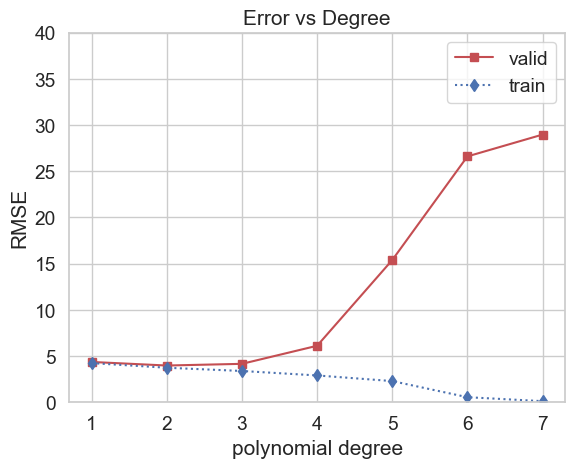

In [95]:
## Question 2A: Error vs Degree

# try all possible degrees from 1 to 7 and 
# record error on training and validation set

# initialize lists according to plot_train_and_valid_error_vs_hyper helper func
degrees = []
err_tr_list1 = []
err_va_list1 = []

# track best performing model
best_model_degree = -1
best_model_va_err1 = np.inf
best_model_test_err1 = np.inf


for deg in range(1, 8):
    degrees.append(deg)

    pipeline = make_pipeline__unpenalized_linear_regr_with_poly_feats(deg)
    pipeline.fit(x_tr_MF, y_tr_M)

    # training error
    tr_y_hat = pipeline.predict(x_tr_MF)
    tr_y_hat = sanitize(tr_y_hat)
    tr_err = sklearn.metrics.root_mean_squared_error(y_tr_M, tr_y_hat)
    err_tr_list1.append(tr_err)

    # validation error
    va_y_hat = pipeline.predict(x_va_NF)
    va_y_hat = sanitize(va_y_hat)
    va_err = sklearn.metrics.root_mean_squared_error(y_va_N, va_y_hat)
    err_va_list1.append(va_err)

    # update and record best test error
    if va_err < best_model_va_err1:
        best_model_degree = deg
        best_model_va_err1 = va_err
        te_y_hat = pipeline.predict(x_te_PF)
        te_y_hat = sanitize(te_y_hat)
        best_model_test_err1 = sklearn.metrics.root_mean_squared_error(y_te_P, te_y_hat)

plot_train_and_valid_error_vs_hyper(degrees, err_tr_list1, err_va_list1, title='Error vs Degree')



In [96]:
print("Best degree:", best_model_degree)
print("Best degree performance on test set (RMSE):", best_model_test_err1)

Best degree: 2
Best degree performance on test set (RMSE): 3.9915025464567604


In [97]:
## Question 2B: Error vs alpha for fixed degree 4

# helper function
def make_pipeline__penalized_linear_regr_with_poly_feats(degree=1, alpha=0):
    pipeline = sklearn.pipeline.Pipeline(
        steps=[
         ('rescaler', sklearn.preprocessing.MinMaxScaler()),
         ('poly_transformer', sklearn.preprocessing.PolynomialFeatures(degree=degree, include_bias=False)),
         ('regr', sklearn.linear_model.Ridge(alpha=alpha))
        ])
    return pipeline

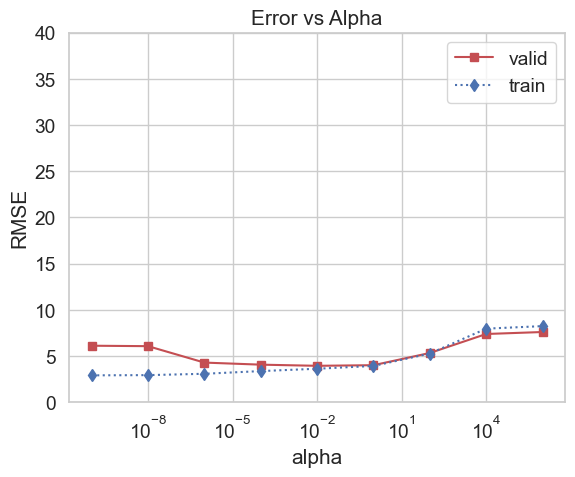

In [98]:
alpha_list = np.asarray([1.e-10, 1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04, 1.e+06])
tr_err_list2 = np.zeros((9,))
va_err_list2 = np.zeros((9,))

fix_degree = 4
best_model_alpha = -1
best_model_va_err2 = np.inf
best_model_test_err2 = np.inf

for idx, a in enumerate(alpha_list):
    pipeline = make_pipeline__penalized_linear_regr_with_poly_feats(fix_degree, a)
    pipeline.fit(x_tr_MF, y_tr_M)

    # training error
    tr_y_hat = pipeline.predict(x_tr_MF)
    tr_y_hat = sanitize(tr_y_hat)
    tr_err = sklearn.metrics.root_mean_squared_error(y_tr_M, tr_y_hat)
    tr_err_list2[idx] = tr_err

    # validation error
    va_y_hat = pipeline.predict(x_va_NF)
    va_y_hat = sanitize(va_y_hat)
    va_err = sklearn.metrics.root_mean_squared_error(y_va_N, va_y_hat)
    va_err_list2[idx] = va_err

    # update and record test error
    if va_err < best_model_va_err2:
        best_model_alpha = a
        best_model_va_err2 = va_err
        te_y_hat = pipeline.predict(x_te_PF)
        te_y_hat = sanitize(te_y_hat)
        best_model_test_err2 = sklearn.metrics.root_mean_squared_error(y_te_P, te_y_hat)


plot_train_and_valid_error_vs_hyper(alpha_list, tr_err_list2, va_err_list2, 
                                    xlabel='alpha', title='Error vs Alpha')
plt.gca().set_xscale('log')
    

In [99]:
print("Best alpha:", best_model_alpha)
print("Best alpha test performance (RMSE):", best_model_test_err2)

Best alpha: 0.01
Best alpha test performance (RMSE): 3.8776678604037524


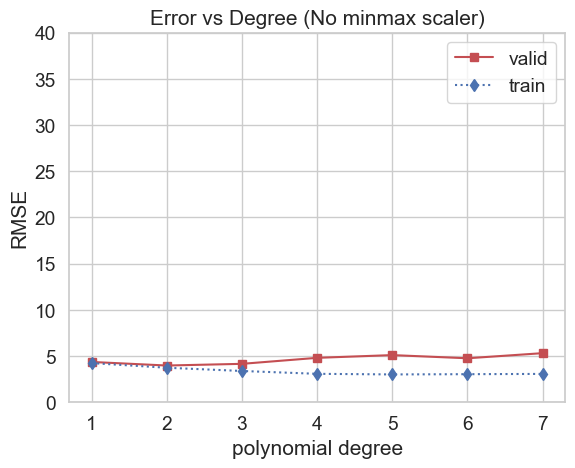

In [100]:
## 2c: removing minmax scaler, repeating what was done in 2a

degrees2 = []
err_tr_list3 = []
err_va_list3 = []

# track best performing model
best_model_degree2 = -1
best_model_va_err3 = np.inf
best_model_test_err3 = np.inf


for deg in range(1, 8):
    degrees2.append(deg)

    pipeline = make_pipeline__unpenalized_linear_regr_with_poly_feats(deg, remove_minmax_scaler=True)
    pipeline.fit(x_tr_MF, y_tr_M)

    # training error
    tr_y_hat = pipeline.predict(x_tr_MF)
    tr_y_hat = sanitize(tr_y_hat)
    tr_err = sklearn.metrics.root_mean_squared_error(y_tr_M, tr_y_hat)
    err_tr_list3.append(tr_err)

    # validation error
    va_y_hat = pipeline.predict(x_va_NF)
    va_y_hat = sanitize(va_y_hat)
    va_err = sklearn.metrics.root_mean_squared_error(y_va_N, va_y_hat)
    err_va_list3.append(va_err)

    # update and record test error
    if va_err < best_model_va_err3:
        best_model_degree2 = deg
        best_model_va_err3 = va_err
        te_y_hat = pipeline.predict(x_te_PF)
        te_y_hat = sanitize(te_y_hat)
        best_model_test_err3 = sklearn.metrics.root_mean_squared_error(y_te_P, te_y_hat)

plot_train_and_valid_error_vs_hyper(degrees2, err_tr_list3, err_va_list3, title='Error vs Degree (No minmax scaler)')



The weight features dominates everything, its value larger than all other features. The other features look "tiny" by comparison and are silently dropped. We scale features so that the model behaves predictably. This is becaue LinearRegression's SVD solver applies an rcond cutoff that zeros out singular values tiny relative to the largest.

In [101]:
## Question 3: Hyperparameter Search with Cross Validation

# prepare data
x_trva_LF = np.vstack([x_tr_MF, x_va_NF])
y_trva_L = np.hstack([y_tr_M, y_va_N])

degree_cv_list = [1, 2, 3, 4, 5, 6, 7]
alpha_cv_list = np.logspace(-10, 6, 17)

In [102]:
K = 10

kf = sklearn.model_selection.KFold(n_splits=K, shuffle=True, random_state=SEED)

best_rmse = np.inf
best_degree, best_alpha = np.inf, np.inf
best_tr_err, best_val_err = np.inf, np.inf
best_test_err = np.inf

for deg in degree_cv_list:
    for alpha in alpha_cv_list:

        total_rmse = 0
        for train_ind, val_ind in kf.split(x_trva_LF, y_trva_L):
            pipeline = make_pipeline__penalized_linear_regr_with_poly_feats(deg, alpha)
            pipeline.fit(x_trva_LF[train_ind], y_trva_L[train_ind])
            y_hat = pipeline.predict(x_trva_LF[val_ind])
            y_hat = sanitize(y_hat)

            total_rmse += sklearn.metrics.root_mean_squared_error(y_hat, y_trva_L[val_ind])
        
        avg_rmse = total_rmse / K # just doing simple average
        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_degree, best_alpha = deg, alpha

            # record best model's training, validation, and test errors
            pipeline = make_pipeline__penalized_linear_regr_with_poly_feats(deg, alpha)
            pipeline.fit(x_tr_MF, y_tr_M)
            y_hat_tr = pipeline.predict(x_tr_MF)
            y_hat_tr = sanitize(y_hat_tr)

            y_hat_va = pipeline.predict(x_va_NF)
            y_hat_va = sanitize(y_hat_va)

            y_hat_te = pipeline.predict(x_te_PF)
            y_hat_te = sanitize(y_hat_te)

            best_tr_err = sklearn.metrics.root_mean_squared_error(y_tr_M, y_hat_tr)
            best_val_err = sklearn.metrics.root_mean_squared_error(y_va_N, y_hat_va)
            best_test_err = sklearn.metrics.root_mean_squared_error(y_te_P, y_hat_te)
        

print("Best combination")
print("Best degree:", best_degree)
print("Best alpha:", best_alpha)
print("Avg Validation RMSE:", best_rmse)
print("Training error:", best_tr_err)
print("Validation error:", best_val_err)
print("Test set error:", best_test_err)

Best combination
Best degree: 7
Best alpha: 0.1
Avg Validation RMSE: 3.859947335404564
Training error: 3.68033236971858
Validation error: 3.941131496369531
Test set error: 3.8820849118165186
